# Tensor Shape debugging

In [28]:
import torch
gs=torch.ones((16,8,77))
q=torch.randn((16,77))

In [29]:
q.unsqueeze(1).repeat(1,8,1)[0][5]

tensor([ 0.5872, -0.0065,  0.7301, -0.3711, -1.2041, -2.2986,  1.2354,  0.8132,
        -2.1675, -1.4143,  1.7160, -0.1610,  0.4236,  0.6768, -0.1887,  1.9470,
         0.2886,  1.0266, -1.2650, -0.4613, -0.2108,  0.7035,  0.5250, -2.2456,
        -0.4772, -0.1649,  1.1898,  1.3275,  0.6831,  0.0264,  0.1471, -0.4743,
        -0.9205,  1.3238,  1.6702, -0.2516, -0.8247, -0.2305,  0.8394, -0.0386,
        -1.5069, -0.5820, -0.4288,  0.5962,  1.4751,  1.5229, -1.9966,  0.7605,
         0.4987,  0.4321, -0.2593,  1.6014, -0.7212,  1.6380, -0.5794,  0.4963,
        -0.1502, -0.6384,  0.8807,  0.4737,  0.2532,  0.3886,  0.2558, -0.7497,
        -0.6710, -0.0345, -0.6441, -1.1315, -1.3246, -0.8875, -0.5085, -1.2757,
        -1.1949, -0.3289, -0.0355, -0.3935,  1.5228])

In [30]:
q[0]

tensor([ 0.5872, -0.0065,  0.7301, -0.3711, -1.2041, -2.2986,  1.2354,  0.8132,
        -2.1675, -1.4143,  1.7160, -0.1610,  0.4236,  0.6768, -0.1887,  1.9470,
         0.2886,  1.0266, -1.2650, -0.4613, -0.2108,  0.7035,  0.5250, -2.2456,
        -0.4772, -0.1649,  1.1898,  1.3275,  0.6831,  0.0264,  0.1471, -0.4743,
        -0.9205,  1.3238,  1.6702, -0.2516, -0.8247, -0.2305,  0.8394, -0.0386,
        -1.5069, -0.5820, -0.4288,  0.5962,  1.4751,  1.5229, -1.9966,  0.7605,
         0.4987,  0.4321, -0.2593,  1.6014, -0.7212,  1.6380, -0.5794,  0.4963,
        -0.1502, -0.6384,  0.8807,  0.4737,  0.2532,  0.3886,  0.2558, -0.7497,
        -0.6710, -0.0345, -0.6441, -1.1315, -1.3246, -0.8875, -0.5085, -1.2757,
        -1.1949, -0.3289, -0.0355, -0.3935,  1.5228])

In [33]:
gs.permute(2,1,0).shape

torch.Size([77, 8, 16])

In [34]:
q.unsqueeze(1).repeat(1,8,1).shape

torch.Size([16, 8, 77])

In [36]:
sim = q.unsqueeze(1).repeat(1,8,1) @ gs.permute(2,1,0)

RuntimeError: The size of tensor a (16) must match the size of tensor b (77) at non-singleton dimension 0

In [37]:
import torch
gs=torch.ones((16,8,512))
q=torch.randn((16,512))

In [ ]:
cos_sims = []
for qfeat_, gfeat_ in zip(q, gs):
    print(qfeat_.shape, gfeat_.shape)
    cos_sim = qfeat_ @ gfeat_.t()#[512]@[k_tta,512].t() = [k_tta]
    print(cos_sim.shape)
    cos_sims.append(cos_sim)
# cos_sims  = torch.cat(cos_sims, dim=0)#16, k_tta

torch.Size([512]) torch.Size([8, 512])
torch.Size([8])
torch.Size([512]) torch.Size([8, 512])
torch.Size([8])
torch.Size([512]) torch.Size([8, 512])
torch.Size([8])
torch.Size([512]) torch.Size([8, 512])
torch.Size([8])
torch.Size([512]) torch.Size([8, 512])
torch.Size([8])
torch.Size([512]) torch.Size([8, 512])
torch.Size([8])
torch.Size([512]) torch.Size([8, 512])
torch.Size([8])
torch.Size([512]) torch.Size([8, 512])
torch.Size([8])
torch.Size([512]) torch.Size([8, 512])
torch.Size([8])
torch.Size([512]) torch.Size([8, 512])
torch.Size([8])
torch.Size([512]) torch.Size([8, 512])
torch.Size([8])
torch.Size([512]) torch.Size([8, 512])
torch.Size([8])
torch.Size([512]) torch.Size([8, 512])
torch.Size([8])
torch.Size([512]) torch.Size([8, 512])
torch.Size([8])
torch.Size([512]) torch.Size([8, 512])
torch.Size([8])
torch.Size([512]) torch.Size([8, 512])
torch.Size([8])


In [44]:
cos_sims = torch.stack(cos_sims)

In [45]:
cos_sims.shape

torch.Size([16, 8])

# Visual Person ReID Dataset

## RTSPReid

- 4101个identity，每个identity有5张图片，每张图片有2个caption
- 训练集3701个identity，测试集200个identity

In [ ]:
import json

with open('/home/jiahao/task/IRRA/input/images/RSTPReid/data_captions.json', 'r') as f:
    annos = json.load(f)

train_anno, test_anno, val_anno = [], [], []
for anno in annos:
    if anno['split'] == 'train':
        train_anno.append(anno)
    elif anno['split'] == 'test':
        test_anno.append(anno)
    else:
        val_anno.append(anno)

In [74]:
print(f"RSTPReid dataset: {len(annos)}")

RSTPReid dataset: 20505


In [75]:
annos[-1]

{'id': 4100,
 'img_path': '4100_c4_0194.jpg',
 'captions': ['This is a walking man who is wearing a dark blue jacket with a yellow shirt inside and a pair of black trousers. His trainers are black with red shoelace.',
  'The man is wearing a dark blue overcoat ,black trousers and black shoes with a yellow shirt under his overcoat.He is walking and carrying his phone on his hand.He is using his phone.'],
 'split': 'test'}

In [76]:
annos[5]

{'id': 1,
 'img_path': '0001_c14_0033.jpg',
 'captions': ['The man is wearing a black coat and dark blue trousers. He walked with a black bag on his back.',
  'A man with black hair, wearing glasses, a gray and black shirt, black pants and black shoes, carrying a black backpack, is walking, a hand in the pocket'],
 'split': 'train'}

In [77]:
print(annos[1])
print(annos[2])
print(annos[3])
print(annos[4])

{'id': 0, 'img_path': '0000_c14_0032.jpg', 'captions': ['He is wearing a grey jacket with a blue shirt inside.He put his hands in his pockets.He is wearing a pair of glasses.He is carrying a black bag.', 'The man with glasses is wearing a grey jacket with a blue shirt inside. He has his hands in his pockets.'], 'split': 'train'}
{'id': 0, 'img_path': '0000_c1_0004.jpg', 'captions': ['This is a man wearing a grey jacket.He is walking with his hands in his pockets.His trousers are black.His shoes are brown.', 'The man is walking.He is wearing a dark grey jacket that is close.His trousers is black.He has a pair of brown shoes.'], 'split': 'train'}
{'id': 0, 'img_path': '0000_c5_0022.jpg', 'captions': ['The man is walking with a black bag.He wears a bright jacket and a pair of black trousers.His shoes is dark tanned.', 'A man with black hair, wearing glasses, a gray and black shirt, black pants and black shoes, carrying a black backpack, is walking, a hand in the pocket'], 'split': 'train'

In [78]:
annos[0]

{'id': 0,
 'img_path': '0000_c14_0031.jpg',
 'captions': ['The man is wearing a grey jacket and a blue shirt.His trousers are black and his shoes are brown.He is walking.',
  'The man is a strong man who is in a grey jacket.His shirt is blue and his trousers is black.'],
 'split': 'train'}

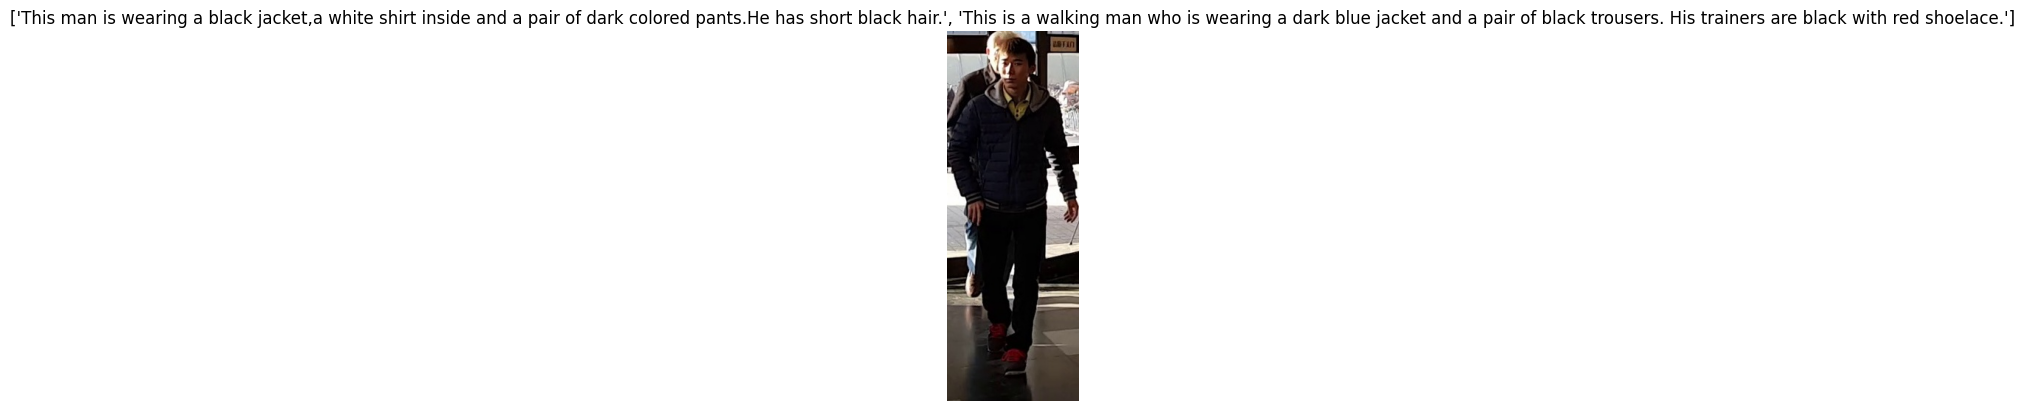

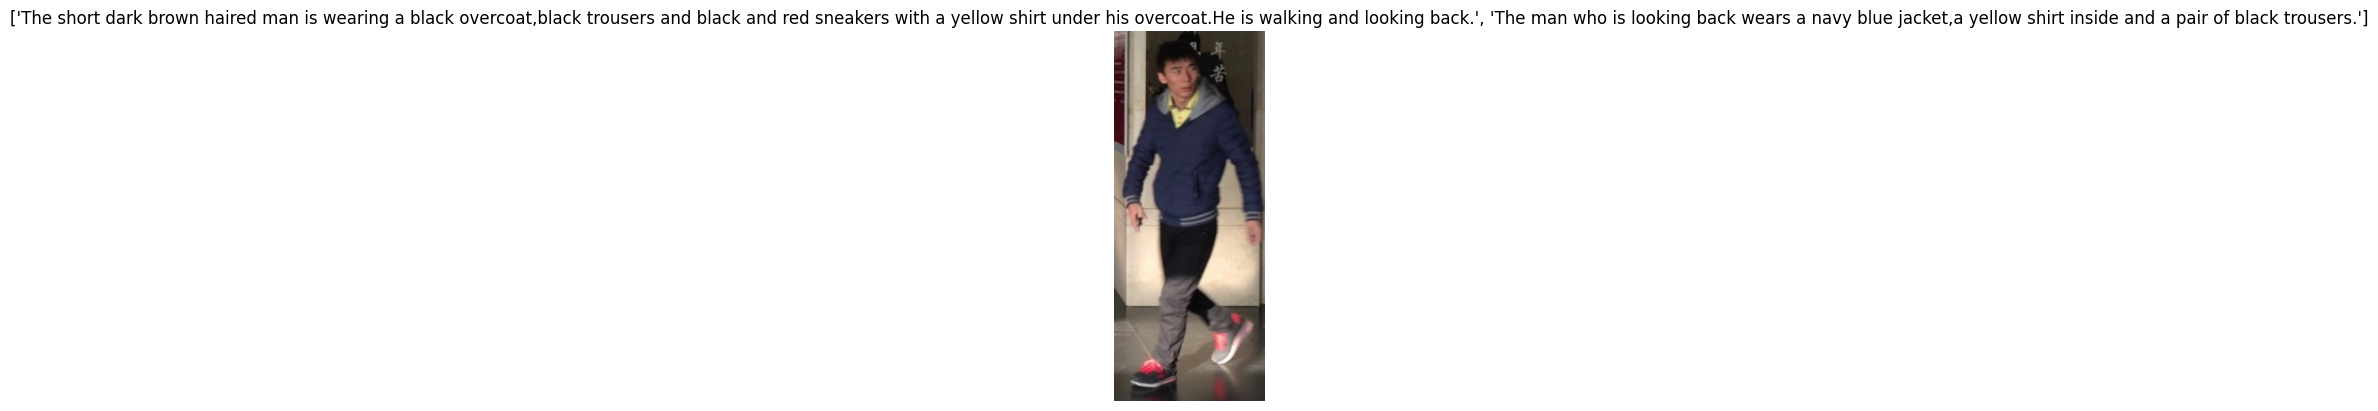

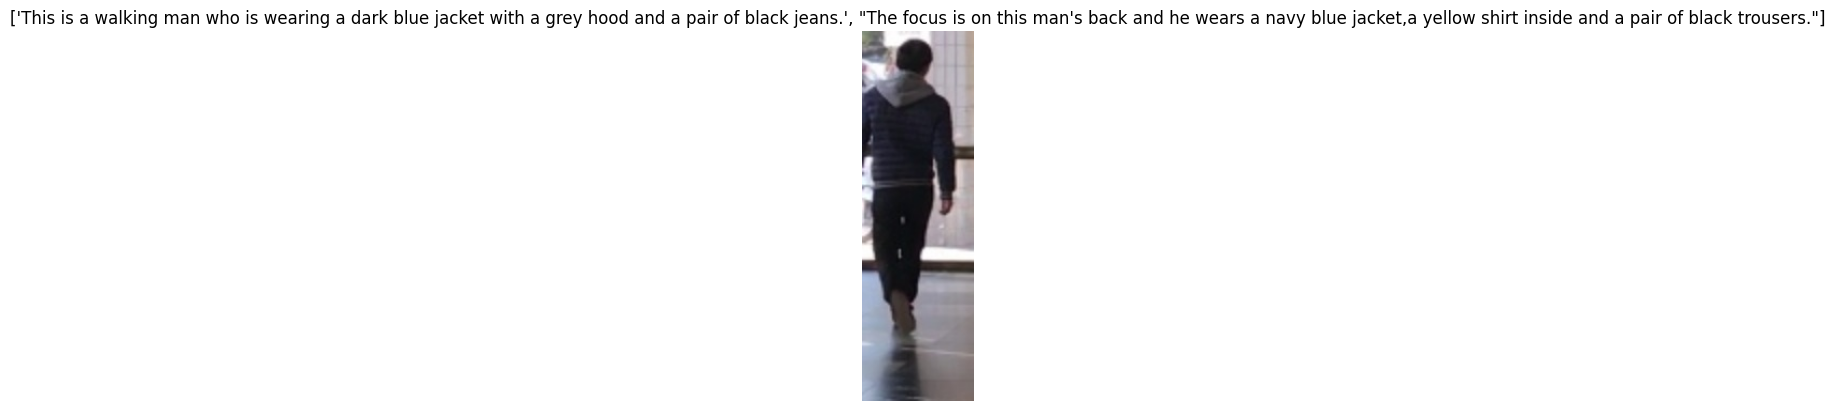

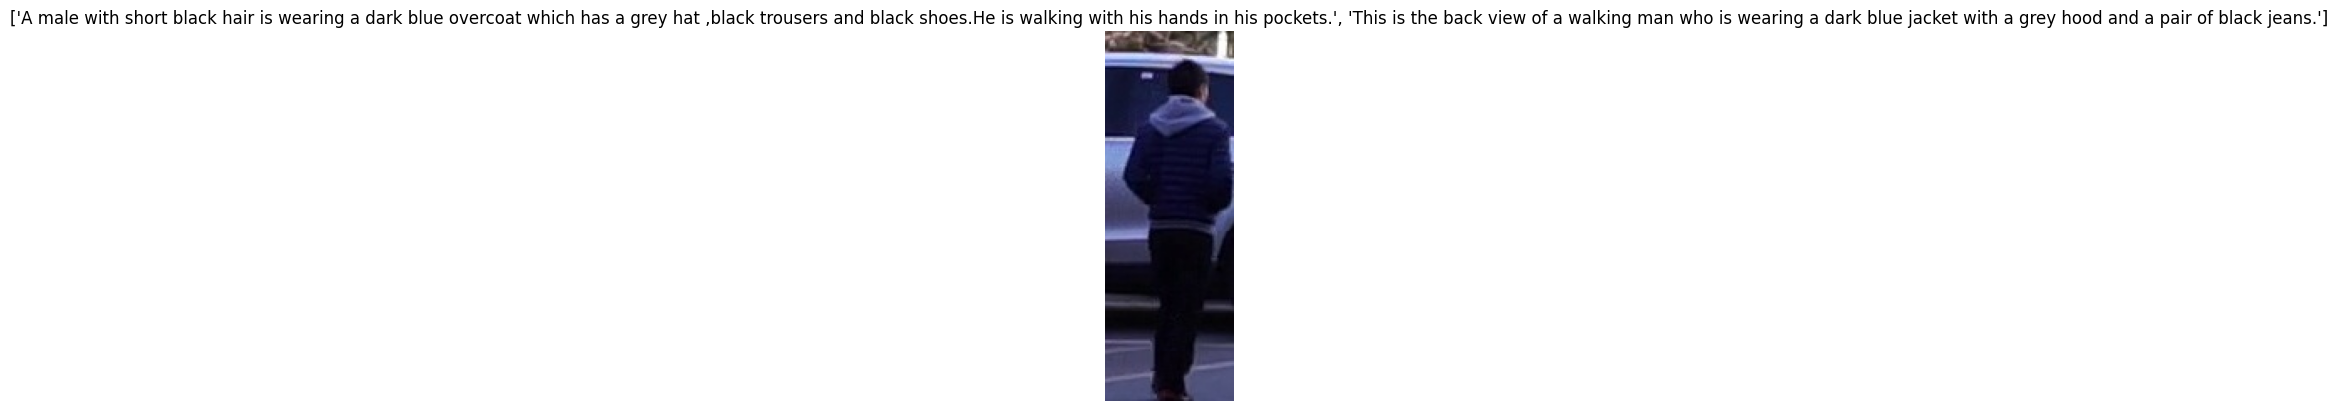

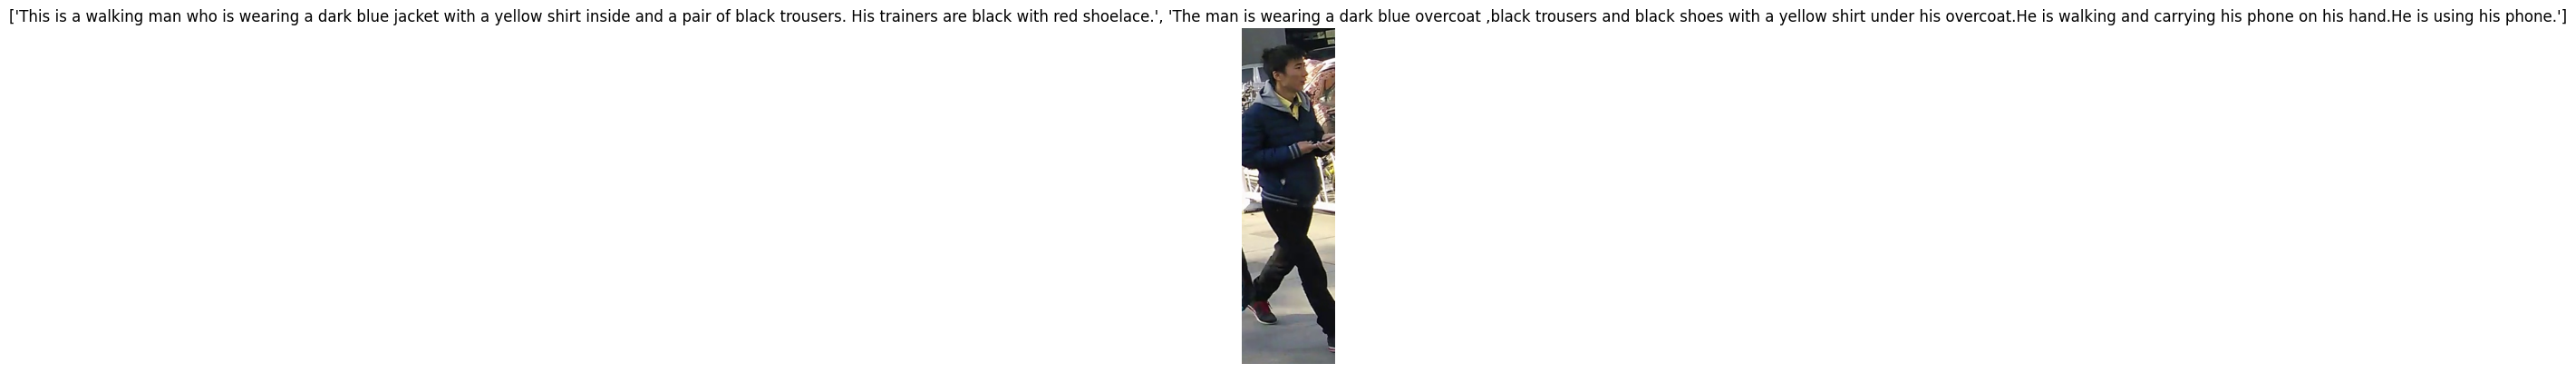

In [82]:
import matplotlib.pyplot as plt
import PIL.Image as Image

RSTP_img_path = '/home/jiahao/task/IRRA/input/images/RSTPReid/imgs'

pid=4100  #4101个identity，每个identity有5张图片，每张图片有2个caption
for i in range(pid*5, (pid+1)*5):
    img = Image.open(f"{RSTP_img_path}/{annos[i]['img_path']}").convert('RGB')
    plt.imshow(img)
    plt.title(annos[i]['captions'])
    plt.axis('off')
    plt.show()


## ICFG-PEDES

- 4102个identity，每个identity平均有13.29张图片，每张图片有1个caption
- 训练集3102个identity,34674张图片；测试集1000个identity，19848张图片

In [ ]:
import json

with open('/home/jiahao/task/IRRA/input/images/ICFG-PEDES/ICFG-PEDES.json', 'r') as f:
    annos = json.load(f)

train_annos, test_annos, val_annos = [], [], []
for anno in annos:
    if anno['split'] == 'train':
        train_annos.append(anno)
    elif anno['split'] == 'test':
        test_annos.append(anno)
    else:
        val_annos.append(anno)

In [102]:
print(f"len(annos) = {len(annos)}")

len(annos) = 54522


In [103]:
annos[0]

{'split': 'train',
 'file_path': 'test/0627/0627_010_05_0303afternoon_1591_0.jpg',
 'id': 0,
 'processed_tokens': [['A',
   'young',
   'age',
   'woman',
   'has',
   'black',
   'shoulder-length',
   'hair',
   'and',
   'her',
   'is',
   'wearing',
   'a',
   'long',
   'grey',
   'collar',
   'jacket',
   'with',
   'white',
   'rounded',
   'neck',
   'inside',
   'with',
   'black',
   'pants',
   'and',
   'black',
   'shoes',
   '.']],
 'captions': ['A young age woman has black shoulder-length hair and her is wearing a long grey collar jacket with white rounded neck inside with black pants and black shoes.']}

In [ ]:
import numpy as np

num_imgs_per_pid = np.zeros(4102)
for anno in annos:
    num_imgs_per_pid[anno['id']] += 1

print('\nall identity img stats: ')
print(len(annos))
print(num_imgs_per_pid.mean())
print(num_imgs_per_pid.max())
print(num_imgs_per_pid.min())
print(num_imgs_per_pid.std())


import numpy as np

num_train_imgs_per_pid = np.zeros(3102)
for anno in train_annos:
    num_train_imgs_per_pid[anno['id']] += 1

print('\ntrain identity img stats: ')
print(len(train_annos))
print(num_train_imgs_per_pid.mean())
print(num_train_imgs_per_pid.max())
print(num_train_imgs_per_pid.min())
print(num_train_imgs_per_pid.std())


import numpy as np

num_test_imgs_per_pid = np.zeros(1000)
for anno in test_annos:
    num_test_imgs_per_pid[anno['id']-3102] += 1

print('\ntest identity img stats: ')
print(len(test_annos))
print(num_test_imgs_per_pid.mean())
print(num_test_imgs_per_pid.max())
print(num_test_imgs_per_pid.min())
print(num_test_imgs_per_pid.std())


all identity img stats: 
54522
13.291565090199903
22.0
3.0
4.734627364726643

train identity img stats: 
34674
11.177949709864604
18.0
3.0
3.343622342244219

test identity img stats: 
19848
19.848
22.0
18.0
0.6549015193141638


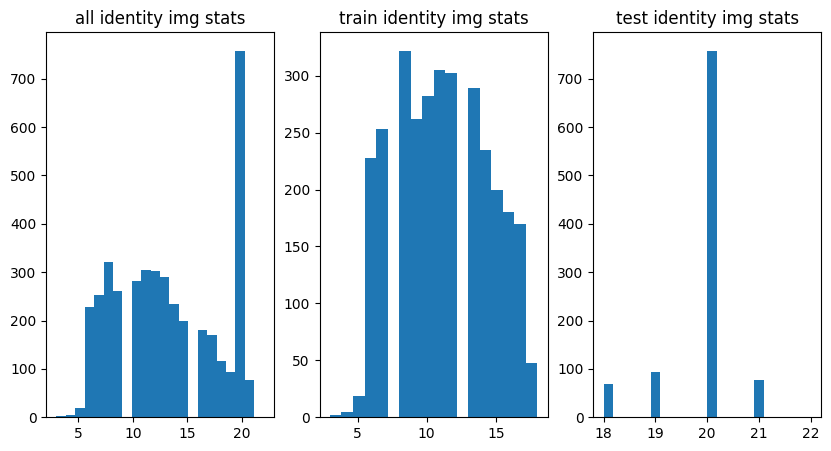

In [110]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.subplot(1,3,1)
plt.hist(num_imgs_per_pid, bins=22)
plt.title('all identity img stats')
plt.subplot(1,3,2)
plt.hist(num_train_imgs_per_pid, bins=18)
plt.title('train identity img stats')
plt.subplot(1,3,3)
plt.hist(num_test_imgs_per_pid, bins=22)
plt.title('test identity img stats')
plt.show()

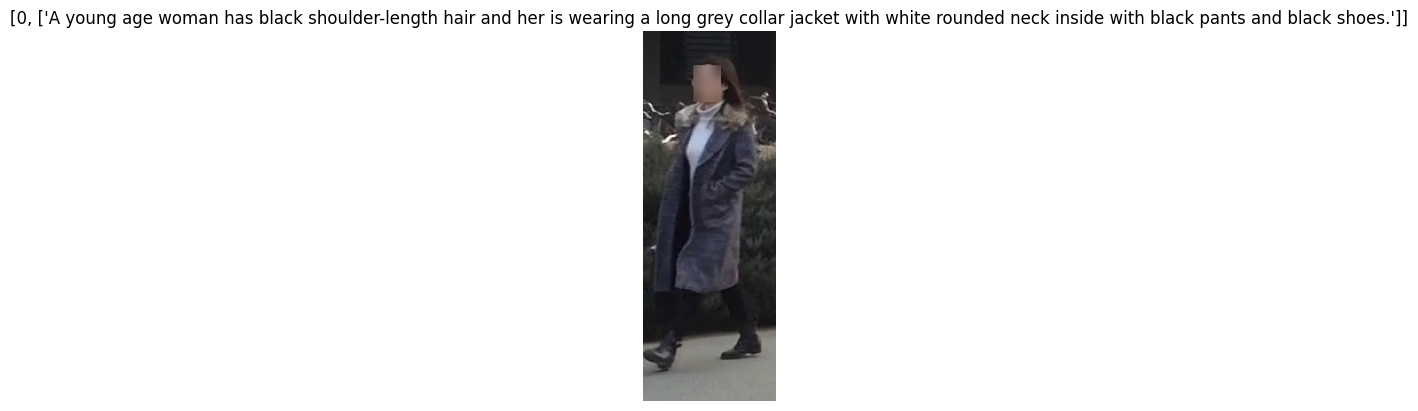

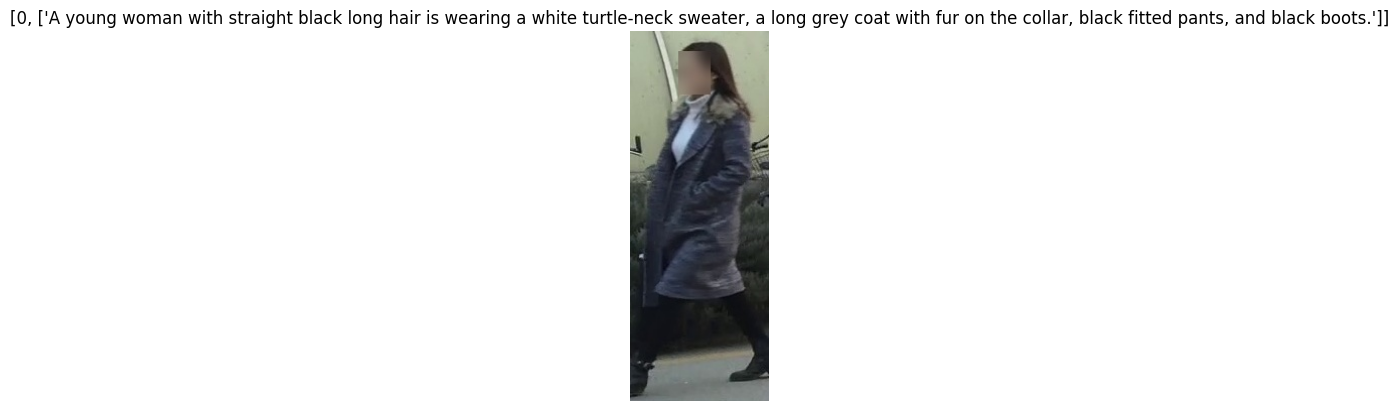

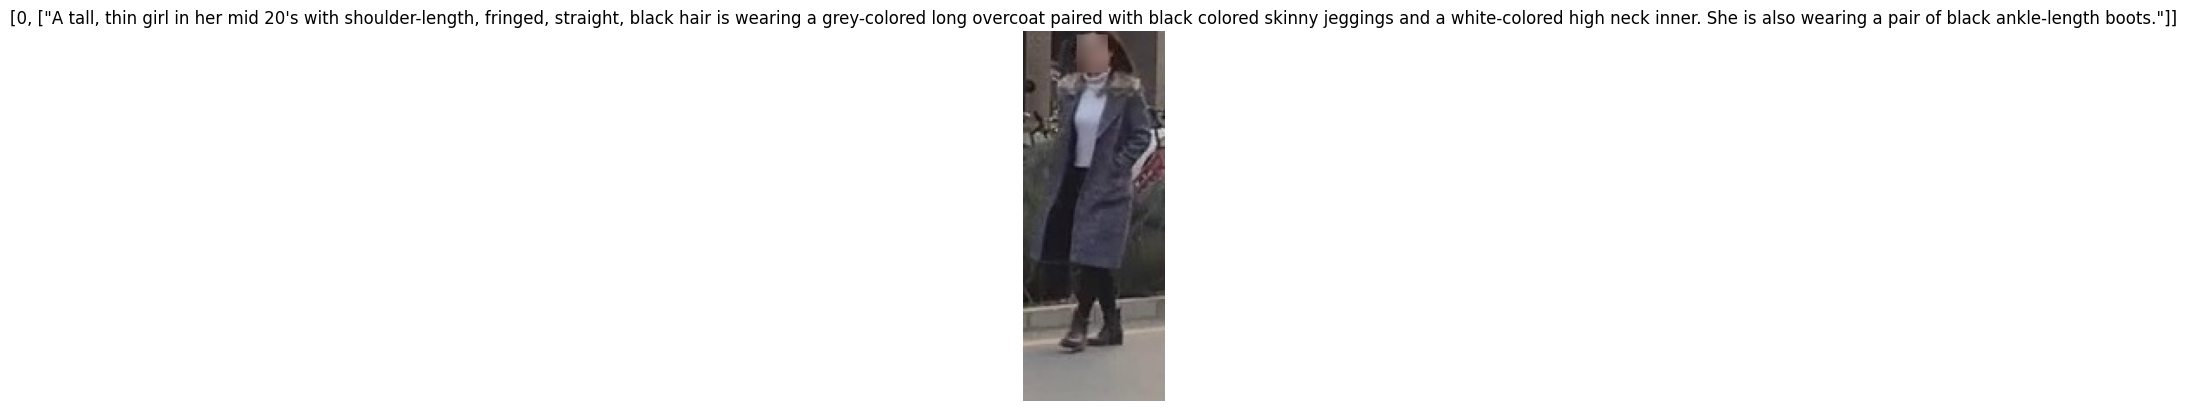

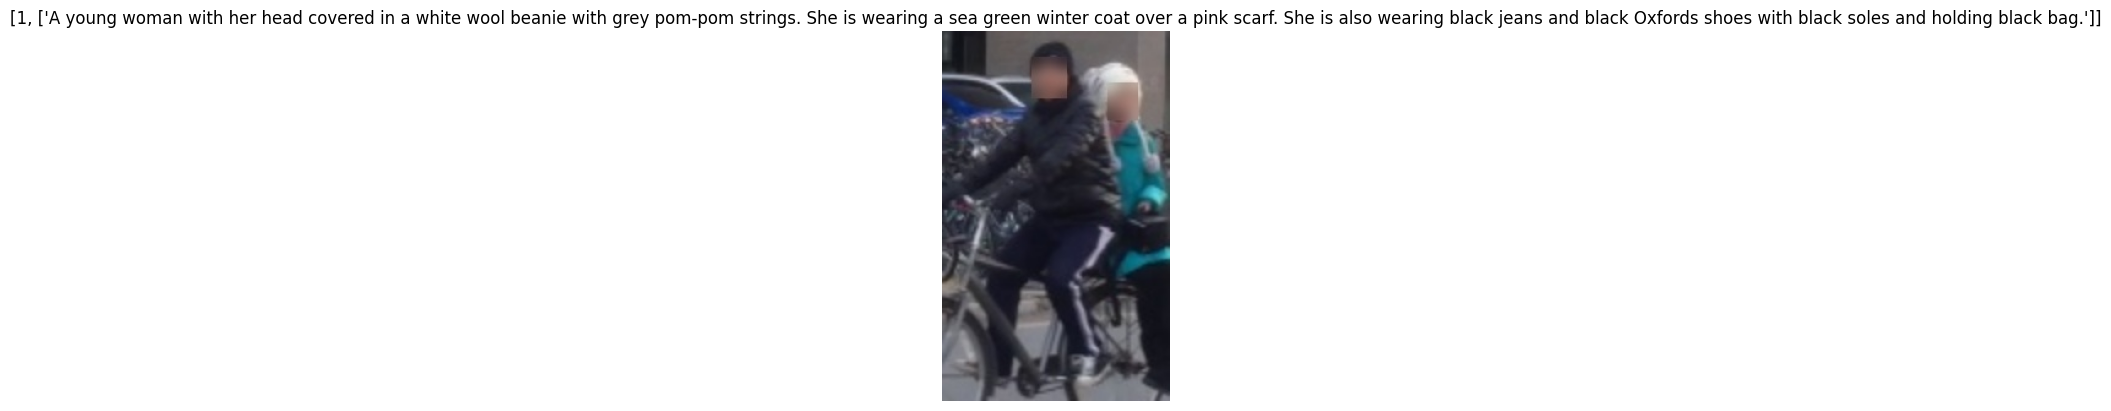

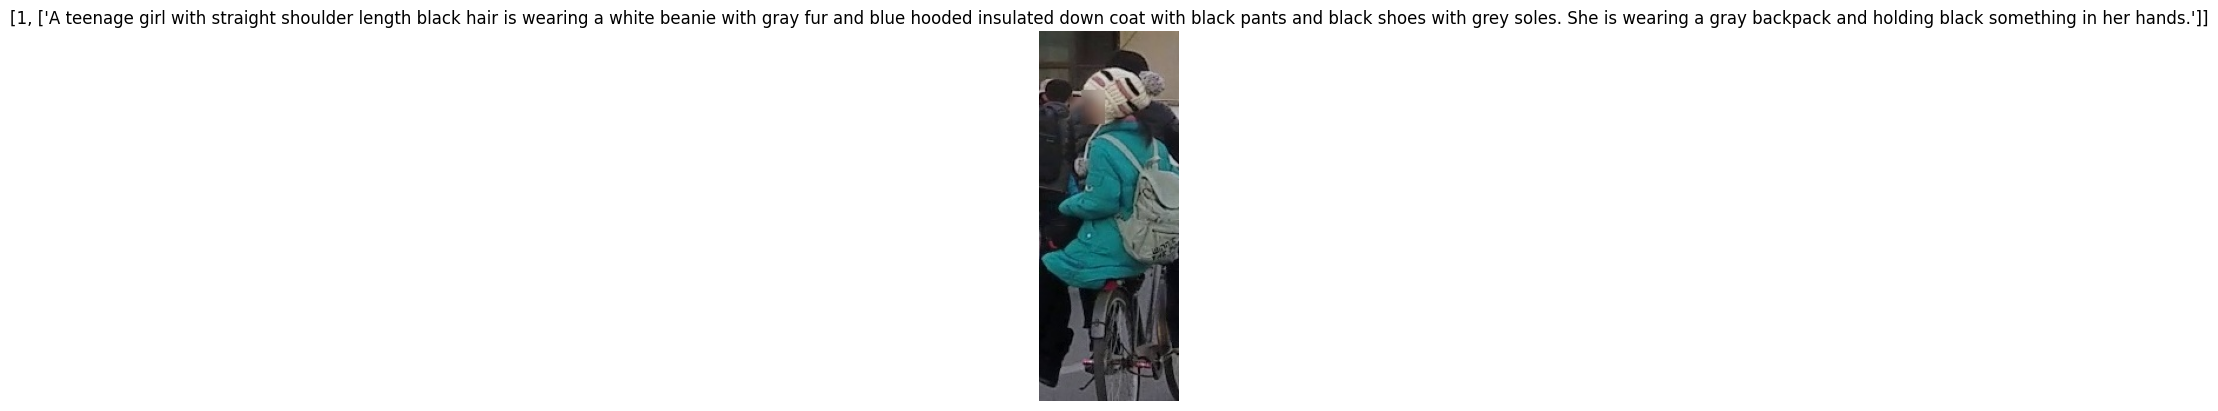

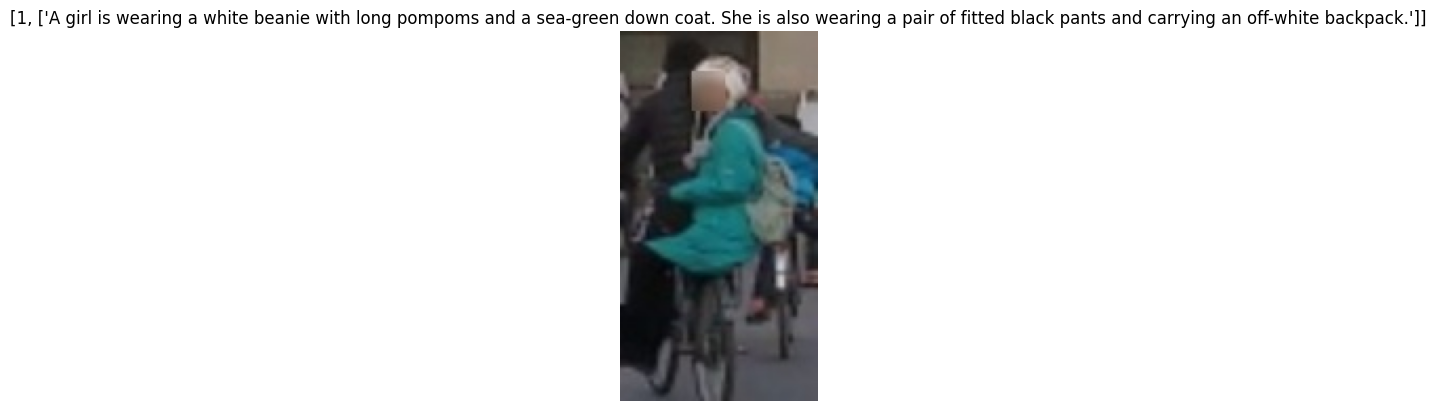

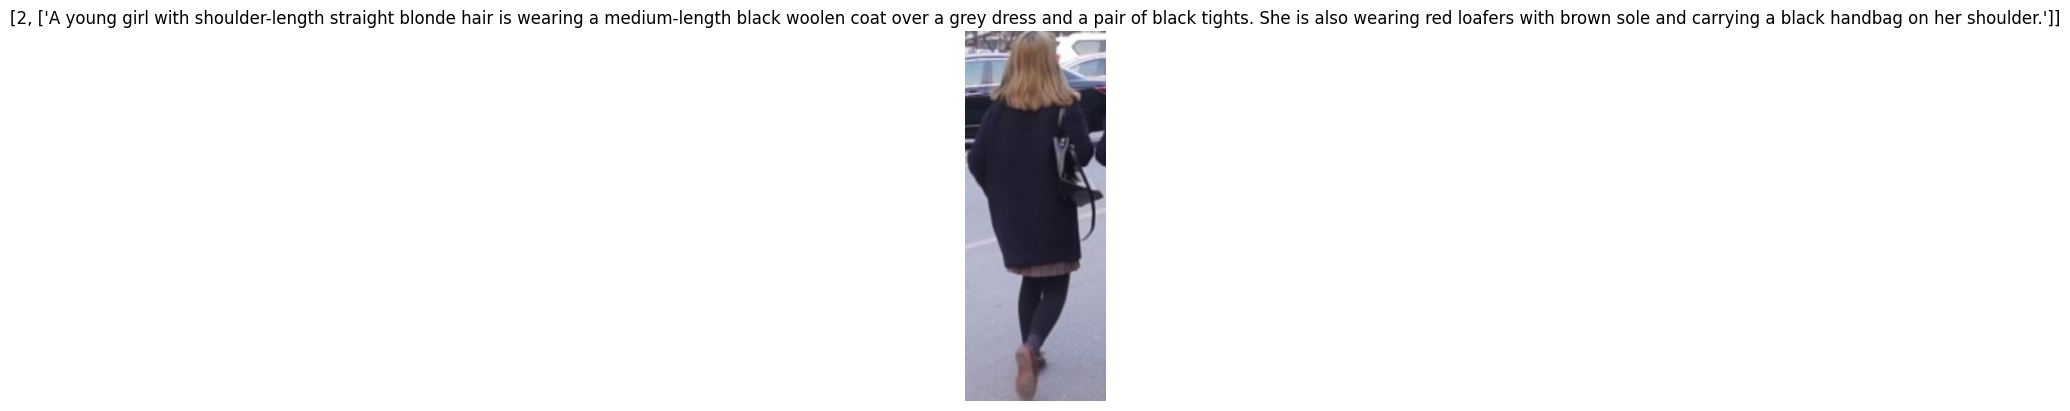

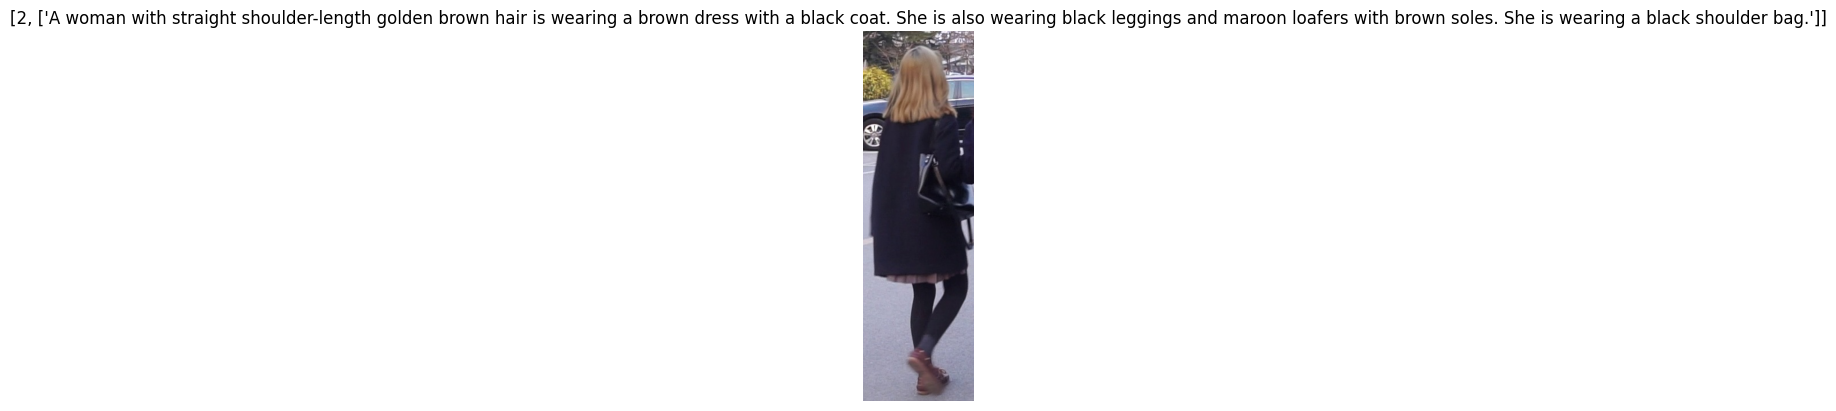

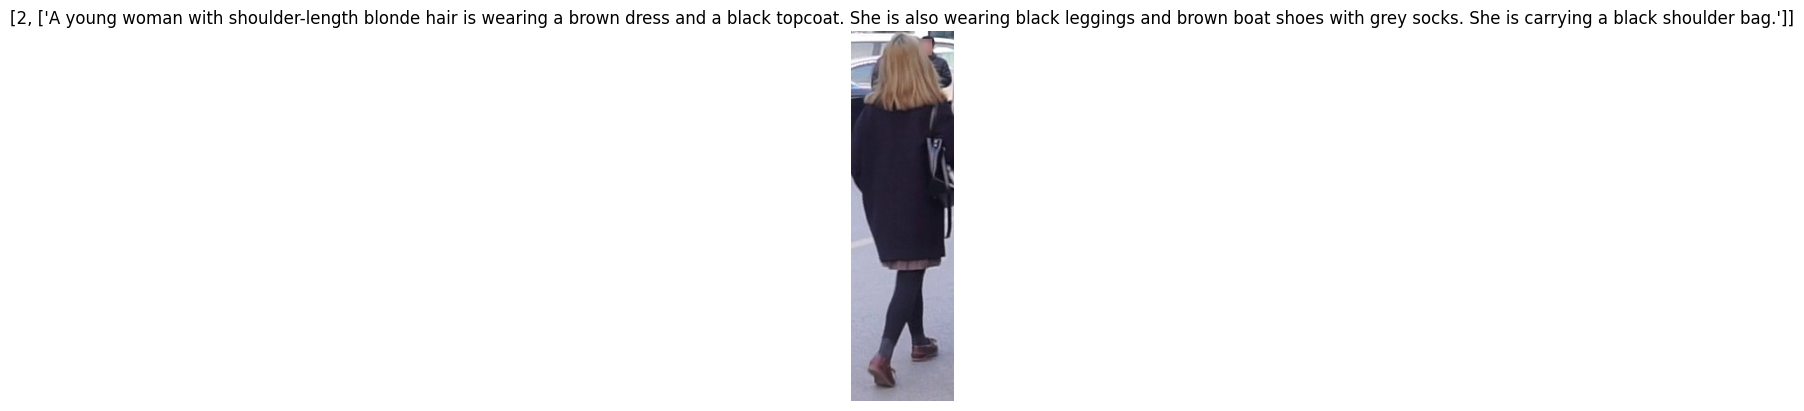

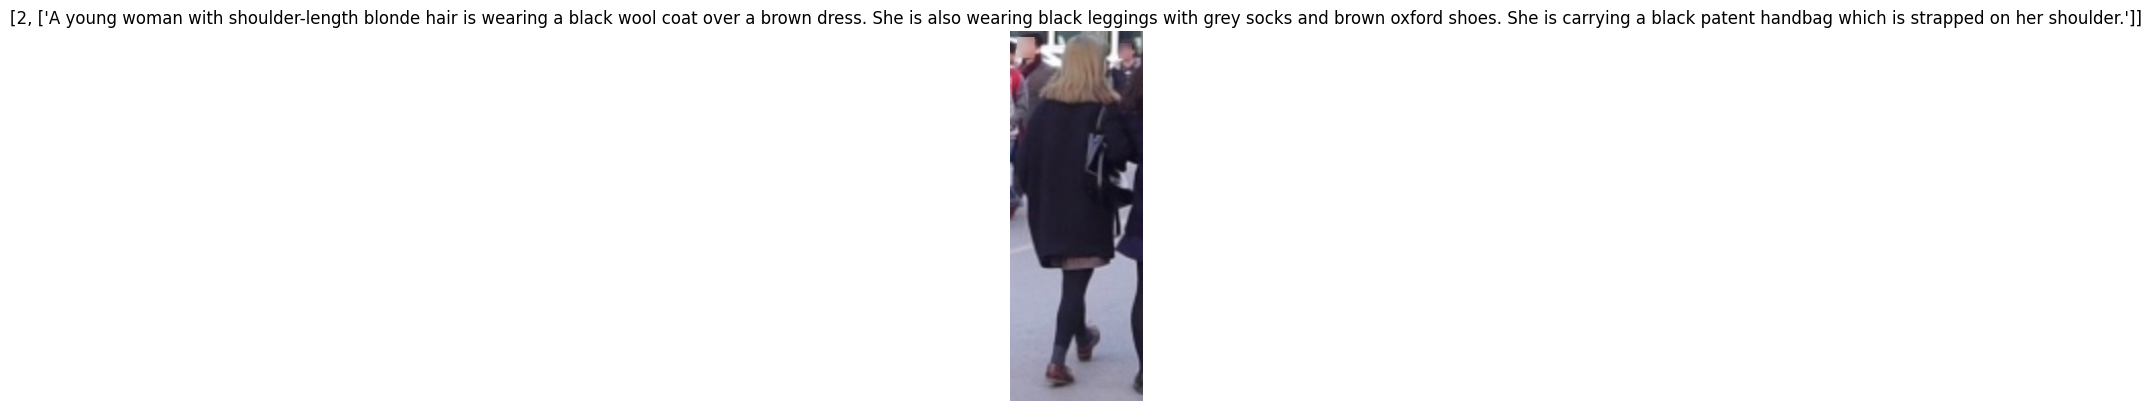

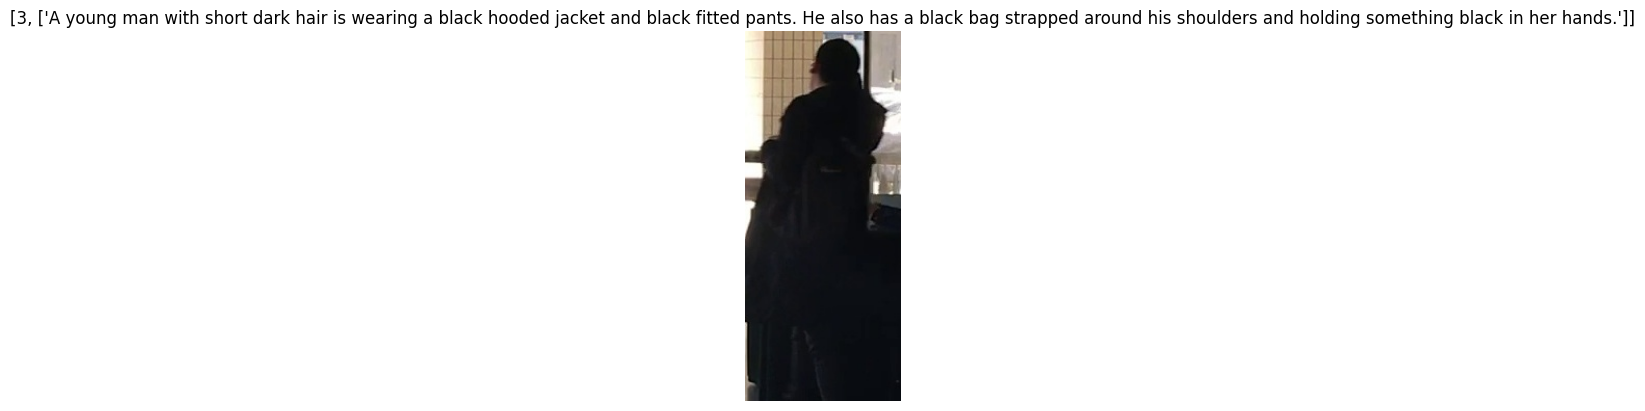

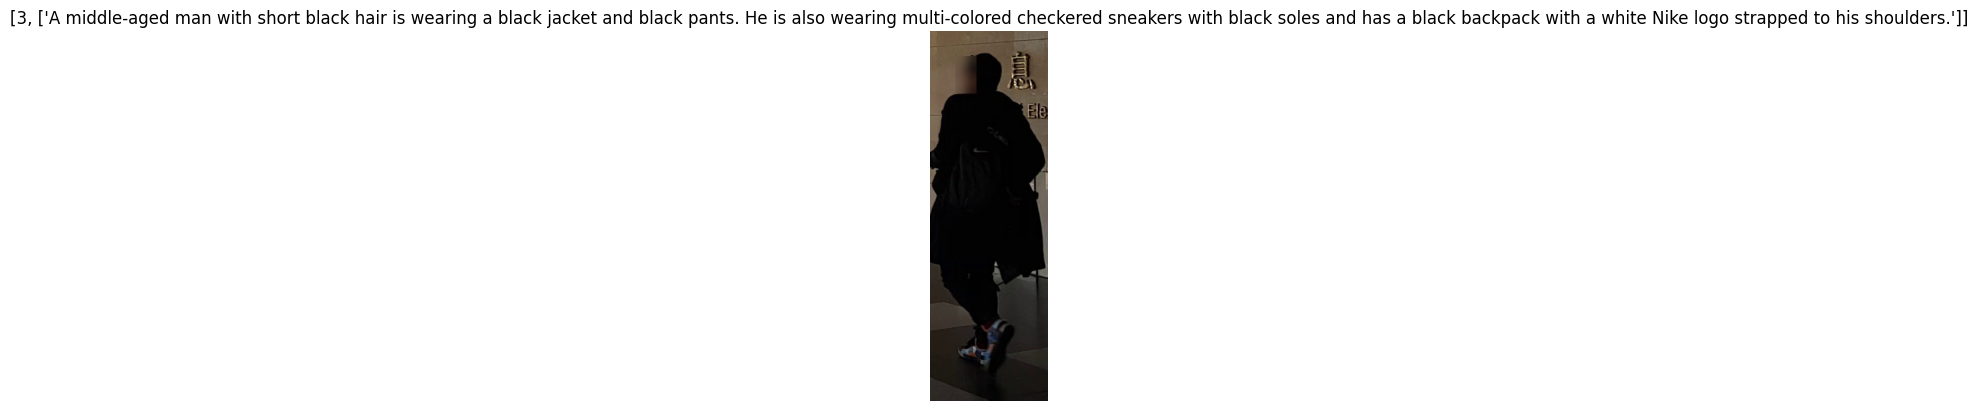

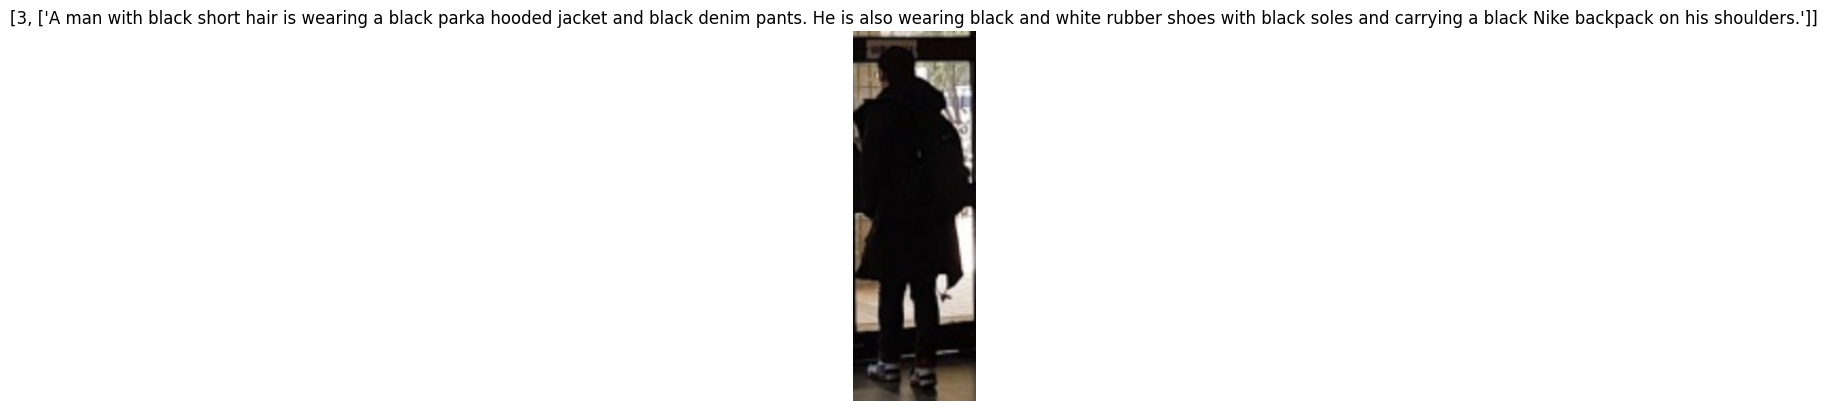

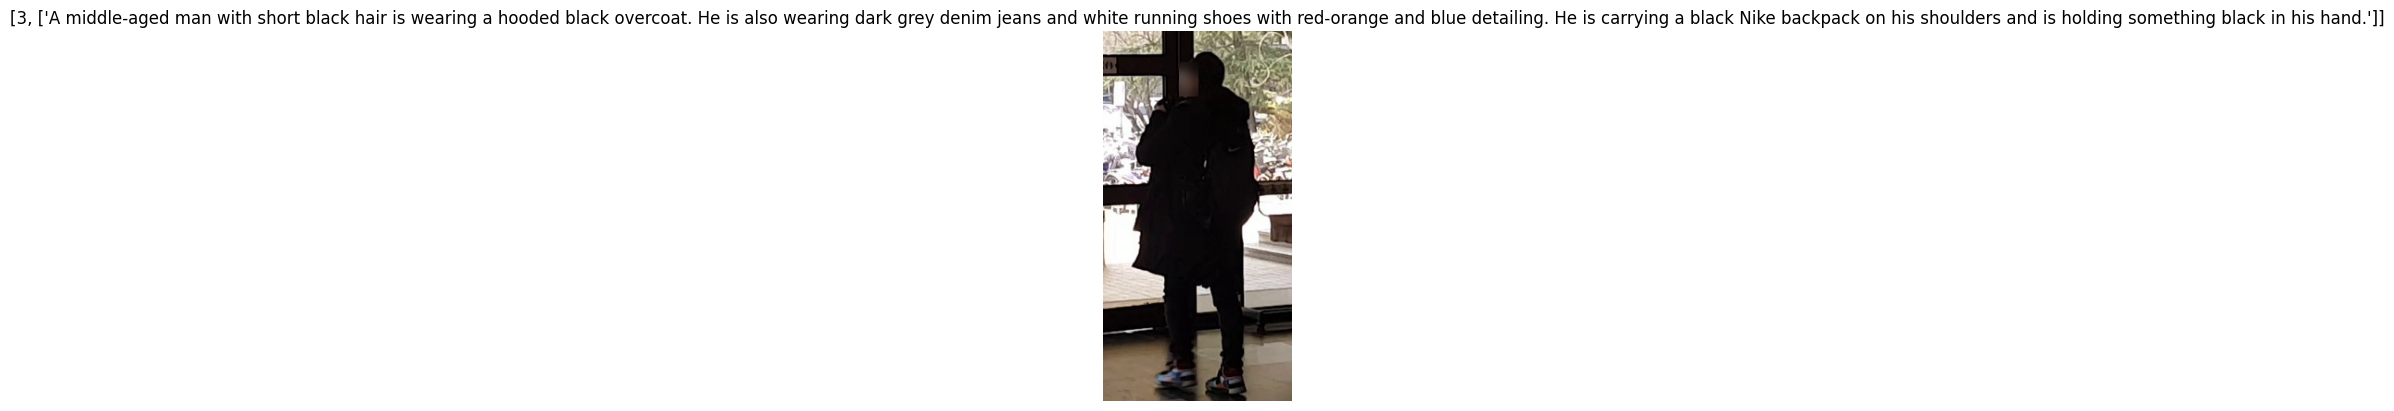

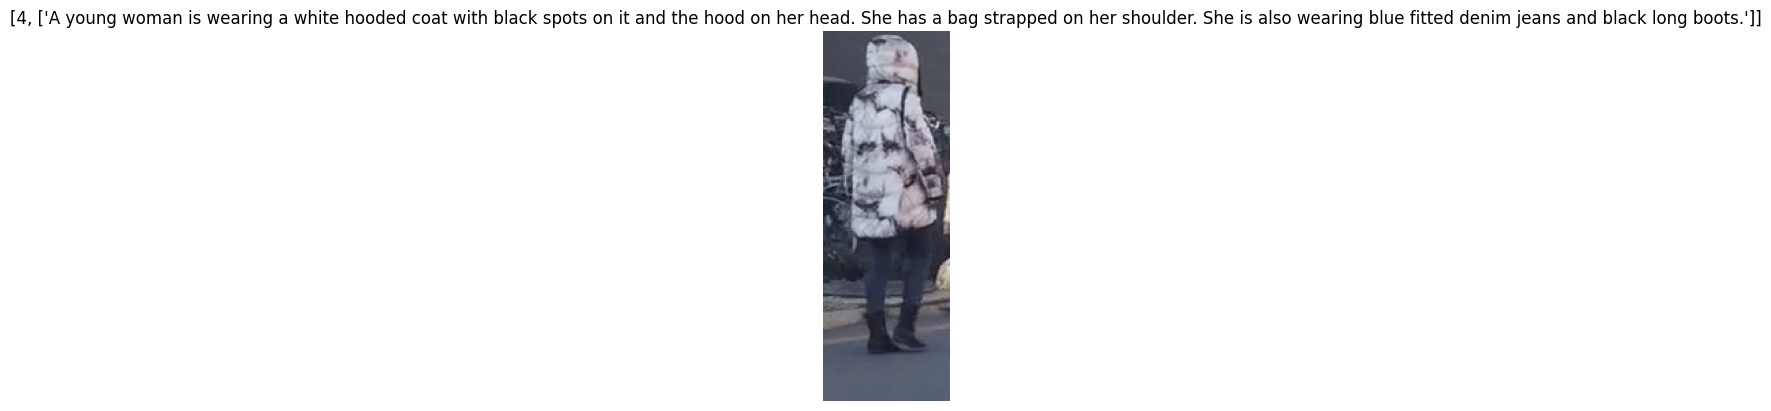

In [ ]:
import matplotlib.pyplot as plt
import PIL.Image as Image

ICFG_img_path = '/home/jiahao/task/IRRA/input/images/ICFG-PEDES/imgs'

pid=0  #4102个identity，每个identity有5张图片，每张图片有2个caption
for i in range(pid*15, (pid+1)*15):
    img = Image.open(f"{ICFG_img_path}/{annos[i]['file_path']}").convert('RGB')
    plt.imshow(img)
    plt.title([annos[i]['id'], annos[i]['captions']])
    plt.axis('off')
    plt.show()


## CUHK-PEDES

- 13003个identity，每个identity平均有3.09张图片，每张图片有2个caption
- 训练集11003个identity,34054张图片，68108个caption；验证集1000个identity，3078张图片，6156个caption；测试集1000个identity，3074张图片，6148个caption

In [130]:

import json

with open('/home/jiahao/task/IRRA/input/images/CUHK-PEDES/reid_raw.json', 'r') as f:
    annos = json.load(f)

train_annos, test_annos, val_annos = [], [], []
for anno in annos:
    if anno['split'] == 'train':
        train_annos.append(anno)
    elif anno['split'] == 'test':
        test_annos.append(anno)
    else:
        val_annos.append(anno)

In [131]:
print(f"len(annos) = {len(annos)}")

len(annos) = 40206


In [132]:
annos[-1]

{'split': 'test',
 'captions': ['The woman is wearing a striped black and grey sweatshirt and dark blue jeans. She is carrying a handbag and wears white shoes.',
  'The woman is wearing a black and grey hoodie. She is wearing dark blue jeans and has a brown bag.'],
 'file_path': 'CUHK01/0681001.png',
 'processed_tokens': [['the',
   'woman',
   'is',
   'wearing',
   'a',
   'striped',
   'black',
   'and',
   'grey',
   'sweatshirt',
   'and',
   'dark',
   'blue',
   'jeans',
   'she',
   'is',
   'carrying',
   'a',
   'handbag',
   'and',
   'wears',
   'white',
   'shoes'],
  ['the',
   'woman',
   'is',
   'wearing',
   'a',
   'black',
   'and',
   'grey',
   'hoodie',
   'she',
   'is',
   'wearing',
   'dark',
   'blue',
   'jeans',
   'and',
   'has',
   'a',
   'brown',
   'bag']],
 'id': 13003}

In [133]:
annos[0]

{'split': 'train',
 'captions': ['A pedestrian with dark hair is wearing red and white shoes, a black hooded sweatshirt, and black pants.',
  'The person has short black hair and is wearing black pants, a long sleeve black top, and red sneakers.'],
 'file_path': 'CUHK01/0363004.png',
 'processed_tokens': [['a',
   'pedestrian',
   'with',
   'dark',
   'hair',
   'is',
   'wearing',
   'red',
   'and',
   'white',
   'shoes',
   'a',
   'black',
   'hooded',
   'sweatshirt',
   'and',
   'black',
   'pants'],
  ['the',
   'person',
   'has',
   'short',
   'black',
   'hair',
   'and',
   'is',
   'wearing',
   'black',
   'pants',
   'a',
   'long',
   'sleeve',
   'black',
   'top',
   'and',
   'red',
   'sneakers']],
 'id': 1}

In [134]:
pids = set()
splits = set()
file_paths = set()
for anno in annos:
    pids.add(anno['id'])
    splits.add(anno['split'])
    file_paths.add(anno['file_path'])

print(len(pids))
print(splits)
print(len(file_paths))



pids = set()
splits = set()
file_paths = set()
for anno in train_annos:
    pids.add(anno['id'])
    splits.add(anno['split'])
    file_paths.add(anno['file_path'])

print(len(pids))
print(splits)
print(len(file_paths))


pids = set()
splits = set()
file_paths = set()
for anno in val_annos:
    pids.add(anno['id'])
    splits.add(anno['split'])
    file_paths.add(anno['file_path'])

print(len(pids))
print(splits)
print(len(file_paths))


pids = set()
splits = set()
file_paths = set()
for anno in test_annos:
    pids.add(anno['id'])
    splits.add(anno['split'])
    file_paths.add(anno['file_path'])

print(len(pids))
print(splits)
print(len(file_paths))



13003
{'train', 'val', 'test'}
40206
11003
{'train'}
34054
1000
{'val'}
3078
1000
{'test'}
3074


In [135]:
import numpy as np


num_imgs_per_pid = np.zeros(13003)
for anno in annos:
    num_imgs_per_pid[anno['id']-1] += 1

print('\nall identity img stats: ')
print(len(annos))
print(num_imgs_per_pid.mean())
print(num_imgs_per_pid.max())
print(num_imgs_per_pid.min())
print(num_imgs_per_pid.std())


num_train_imgs_per_pid = np.zeros(11003)
for anno in train_annos:
    num_train_imgs_per_pid[anno['id']-1] += 1

print('\ntrain identity img stats: ')
print(len(train_annos))
print(num_train_imgs_per_pid.mean())
print(num_train_imgs_per_pid.max())
print(num_train_imgs_per_pid.min())
print(num_train_imgs_per_pid.std())


num_val_imgs_per_pid = np.zeros(1000)
for anno in val_annos:
    num_val_imgs_per_pid[anno['id']-1-11003] += 1

print('\nval identity img stats: ')
print(len(val_annos))
print(num_val_imgs_per_pid.mean())
print(num_val_imgs_per_pid.max())
print(num_val_imgs_per_pid.min())
print(num_val_imgs_per_pid.std())


num_test_imgs_per_pid = np.zeros(1000)
for anno in test_annos:
    num_test_imgs_per_pid[anno['id']-1-12003] += 1

print('\ntest identity img stats: ')
print(len(test_annos))
print(num_test_imgs_per_pid.mean())
print(num_test_imgs_per_pid.max())
print(num_test_imgs_per_pid.min())
print(num_test_imgs_per_pid.std())


all identity img stats: 
40206
3.0920556794585865
15.0
1.0
1.121092832369439

train identity img stats: 
34054
3.09497409797328
15.0
1.0
1.1265371240278559

val identity img stats: 
3078
3.078
12.0
2.0
1.0999618175191357

test identity img stats: 
3074
3.074
10.0
1.0
1.0809828860809962


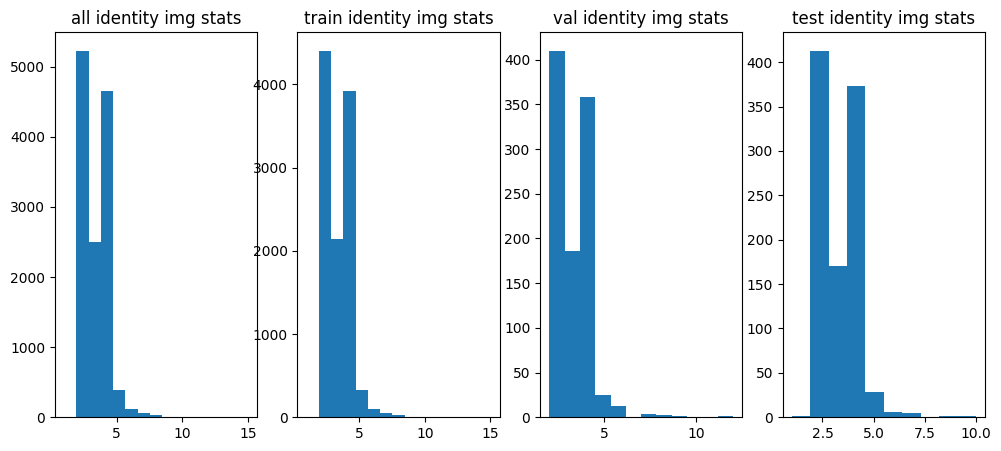

In [136]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.subplot(1,4,1)
plt.hist(num_imgs_per_pid, bins=15)
plt.title('all identity img stats')
plt.subplot(1,4,2)
plt.hist(num_train_imgs_per_pid, bins=15)
plt.title('train identity img stats')
plt.subplot(1,4,3)
plt.hist(num_val_imgs_per_pid, bins=12)
plt.title('val identity img stats')
plt.subplot(1,4,4)
plt.hist(num_test_imgs_per_pid, bins=10)
plt.title('test identity img stats')
plt.show()

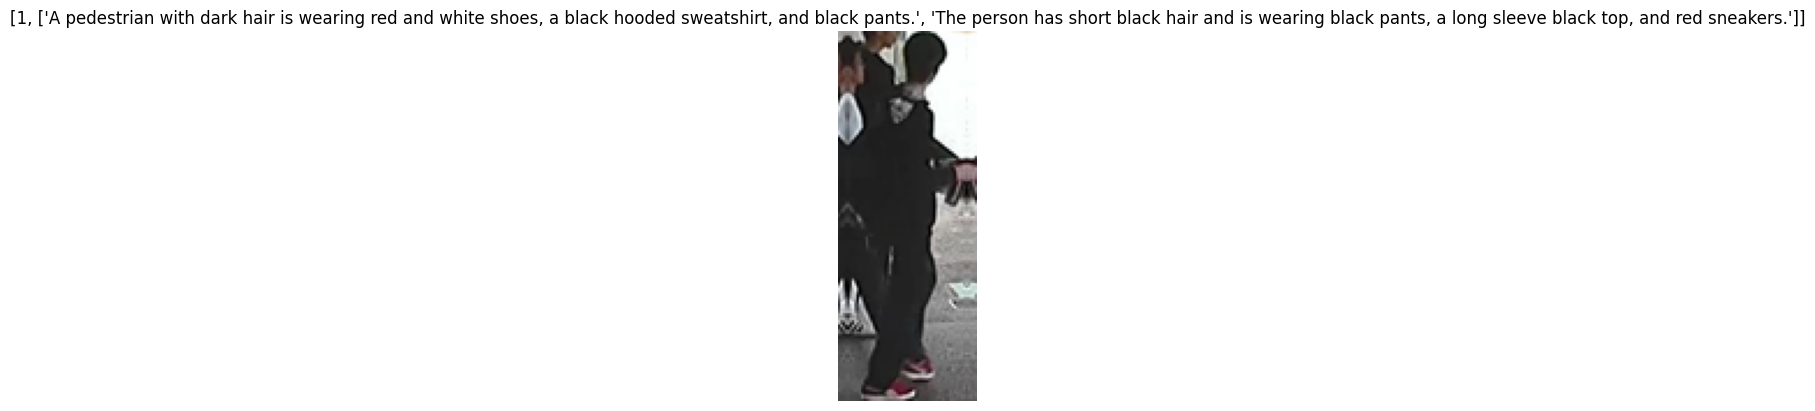

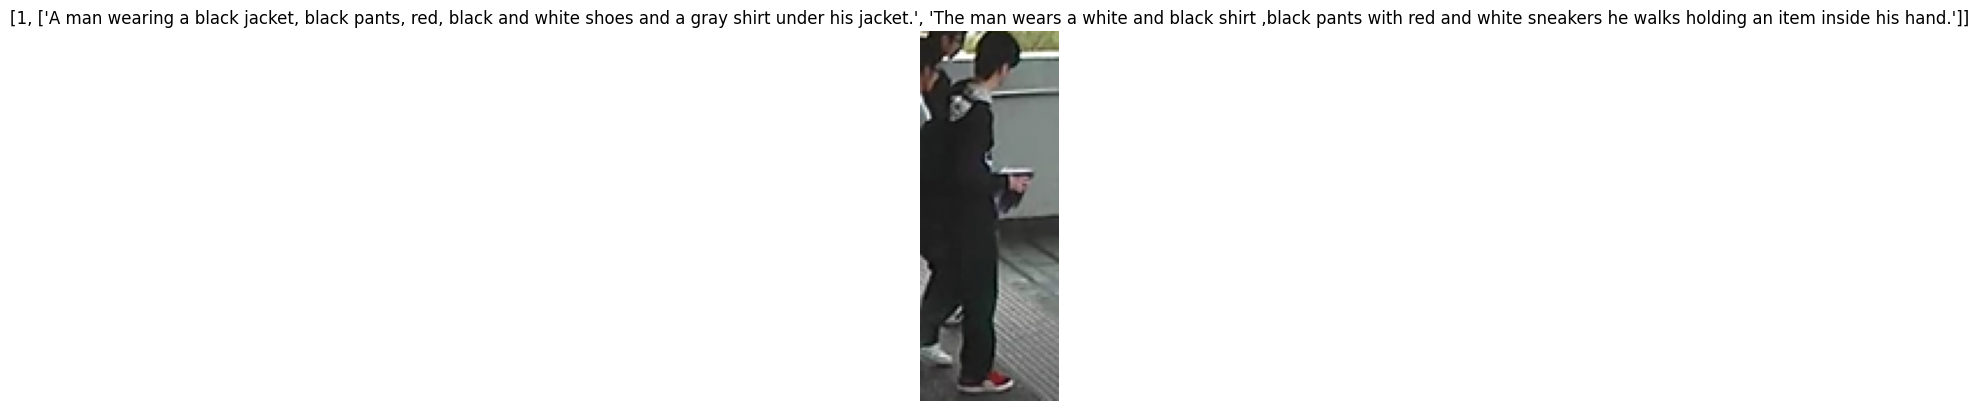

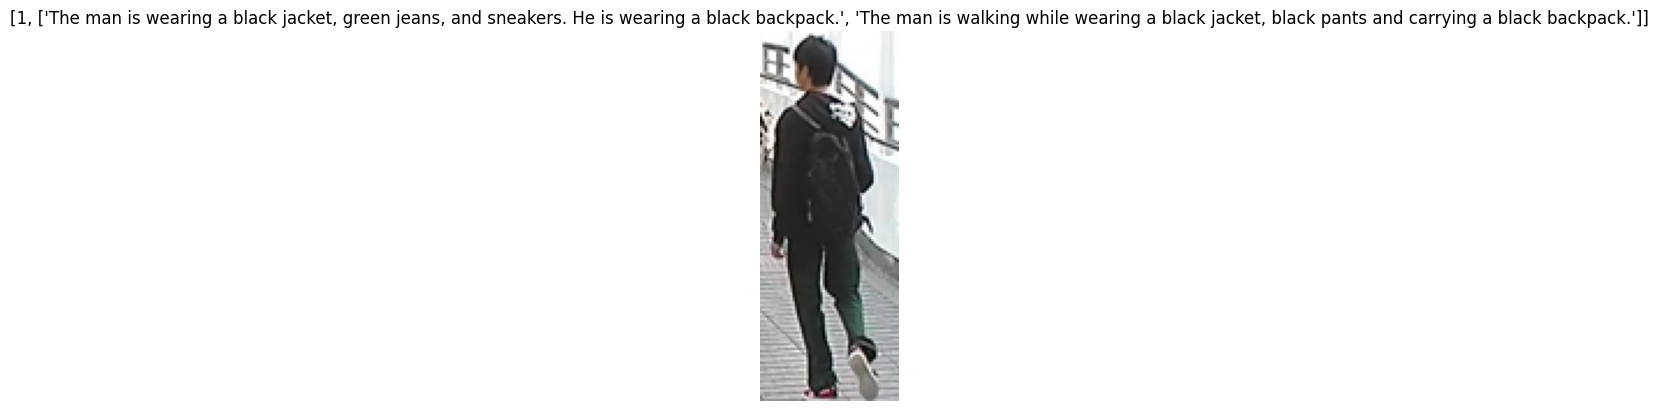

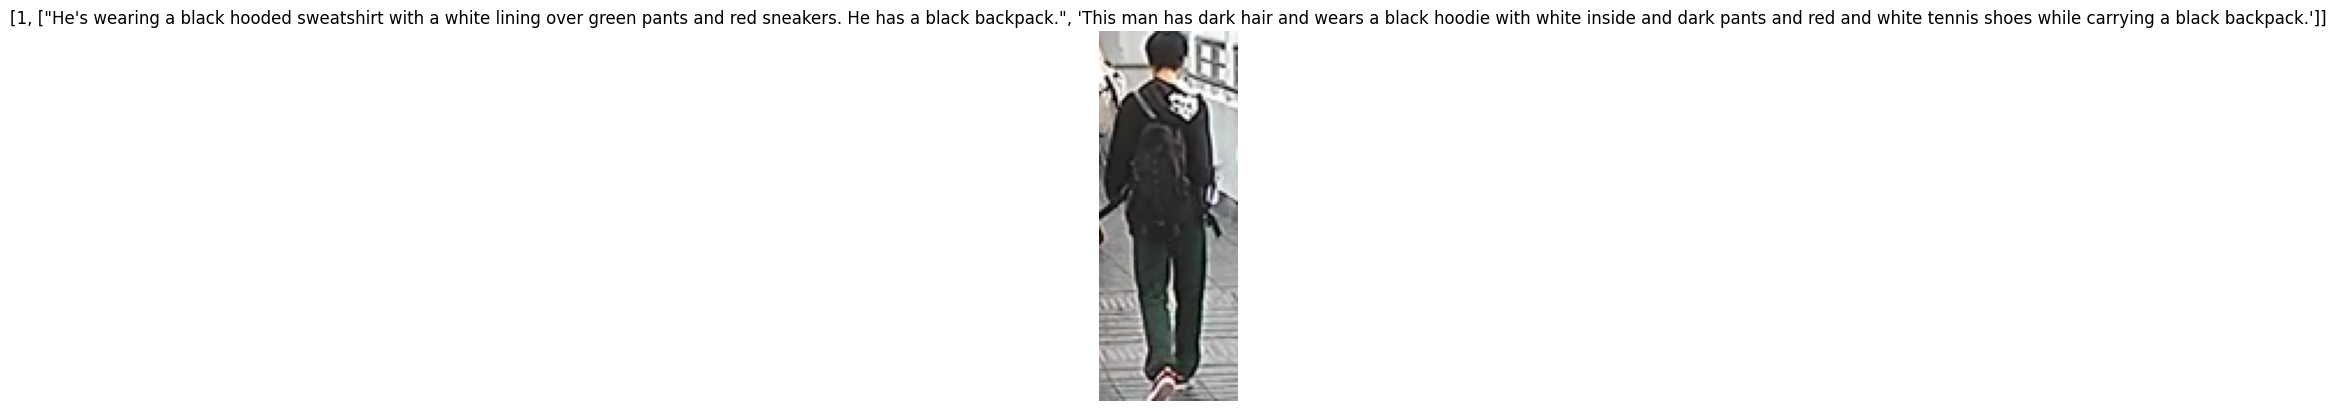

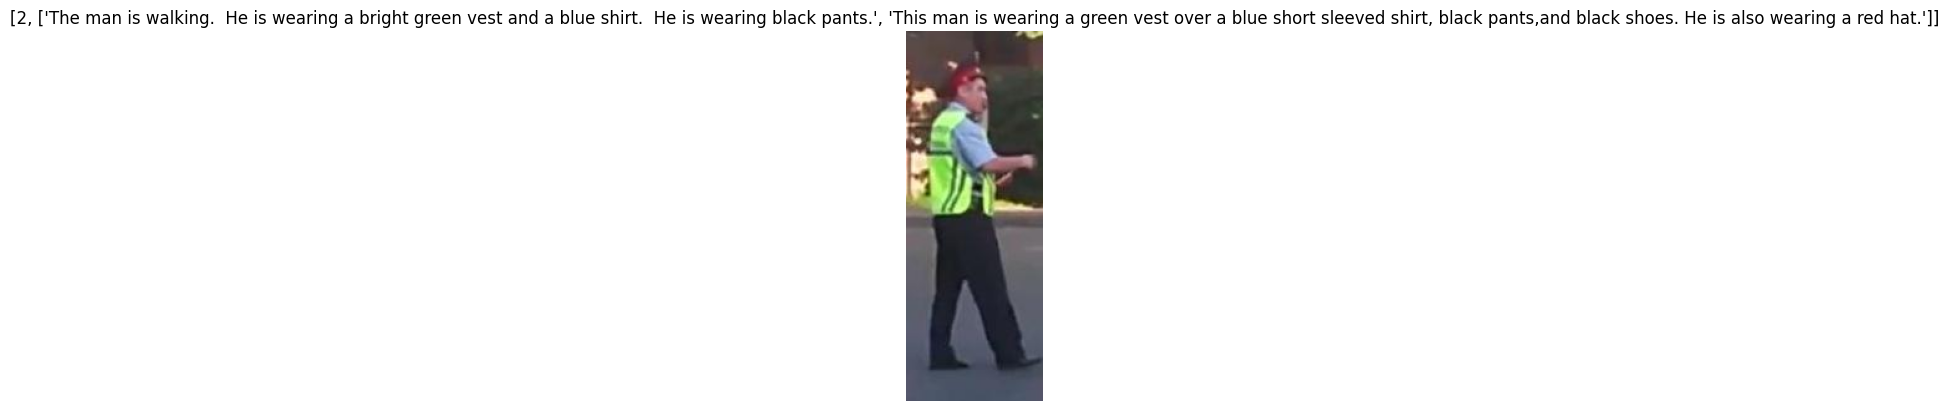

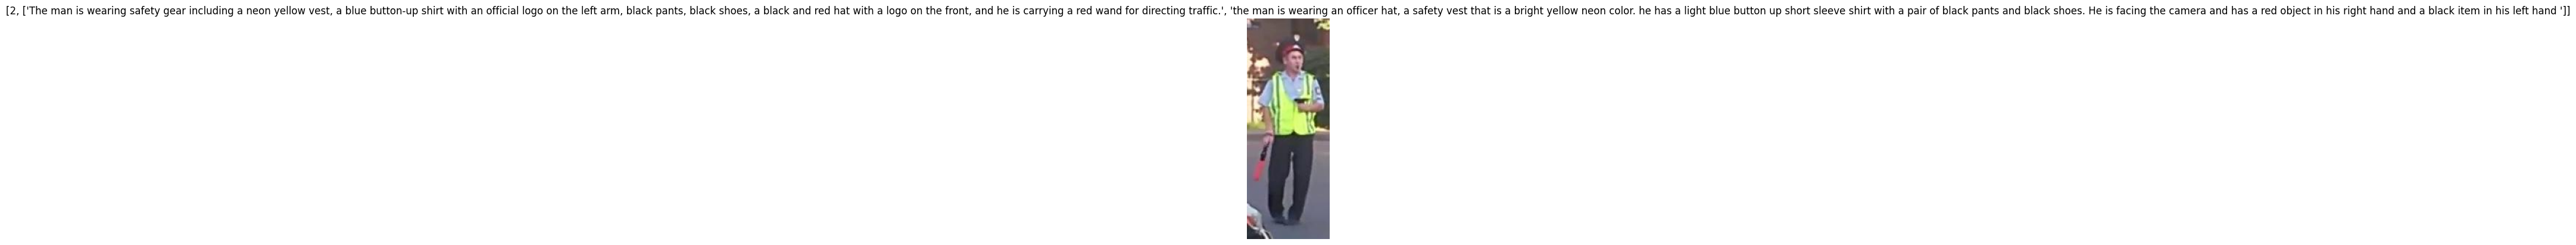

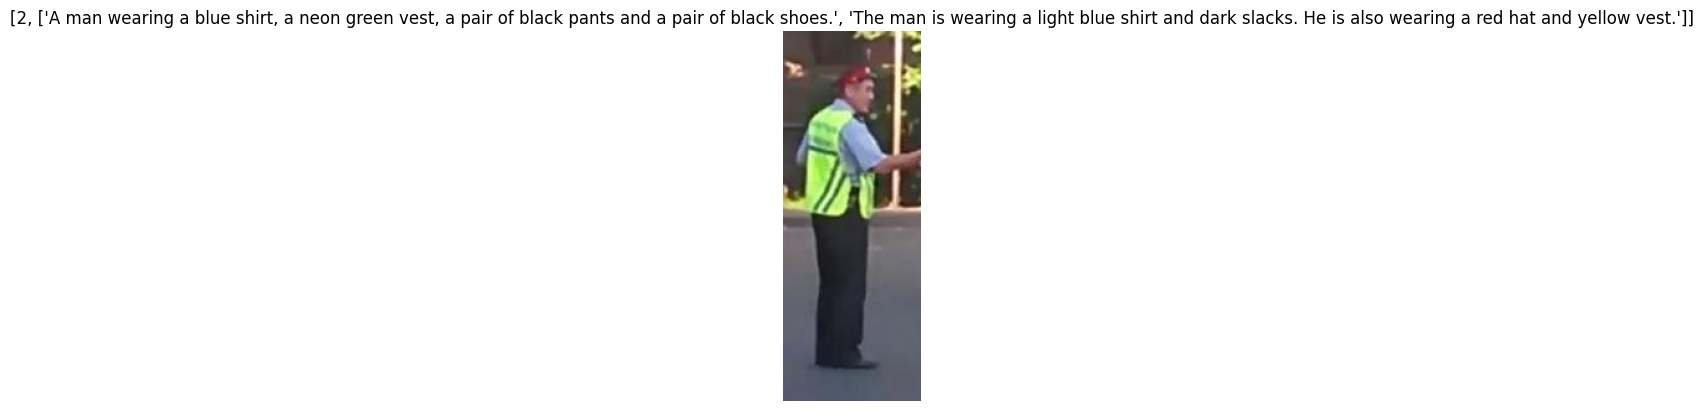

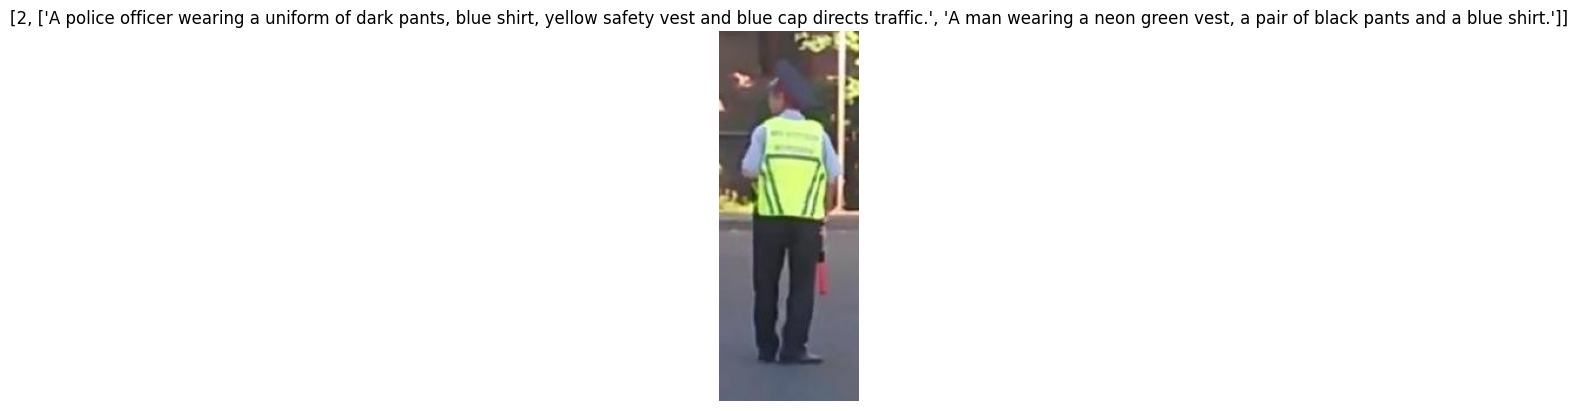

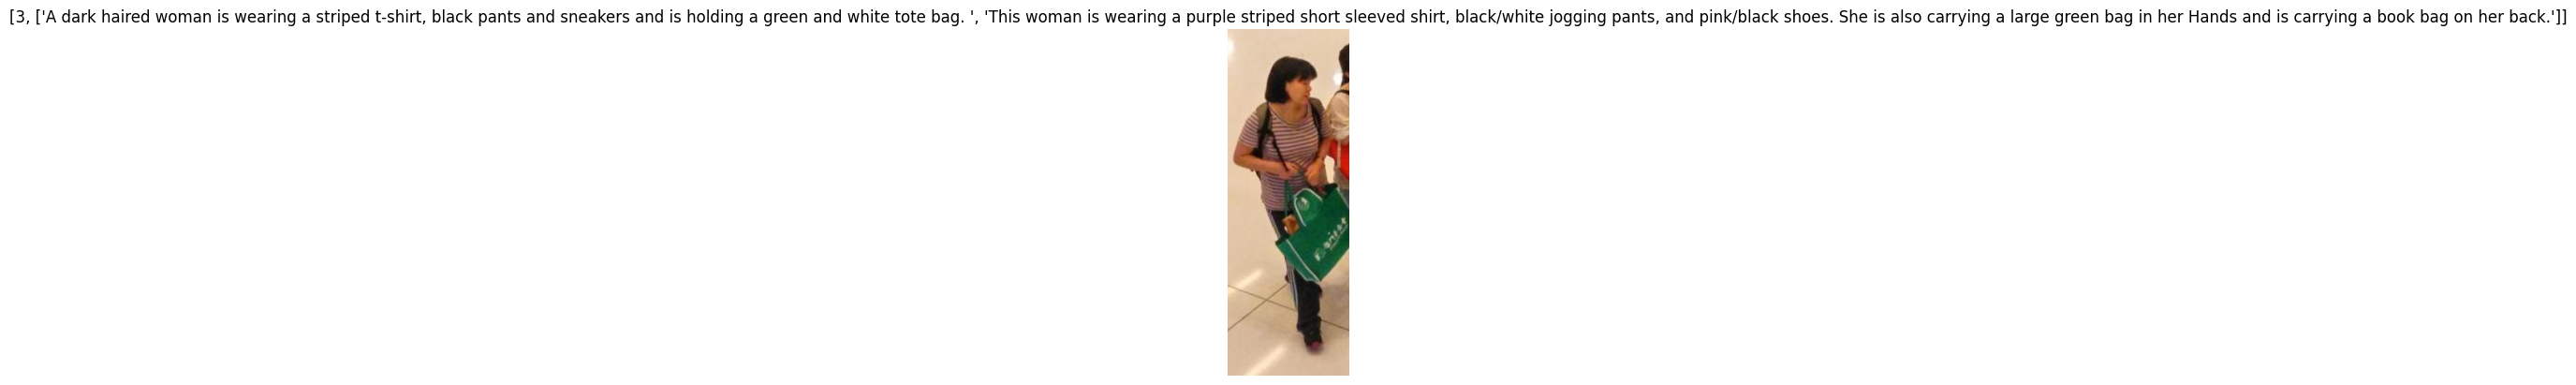

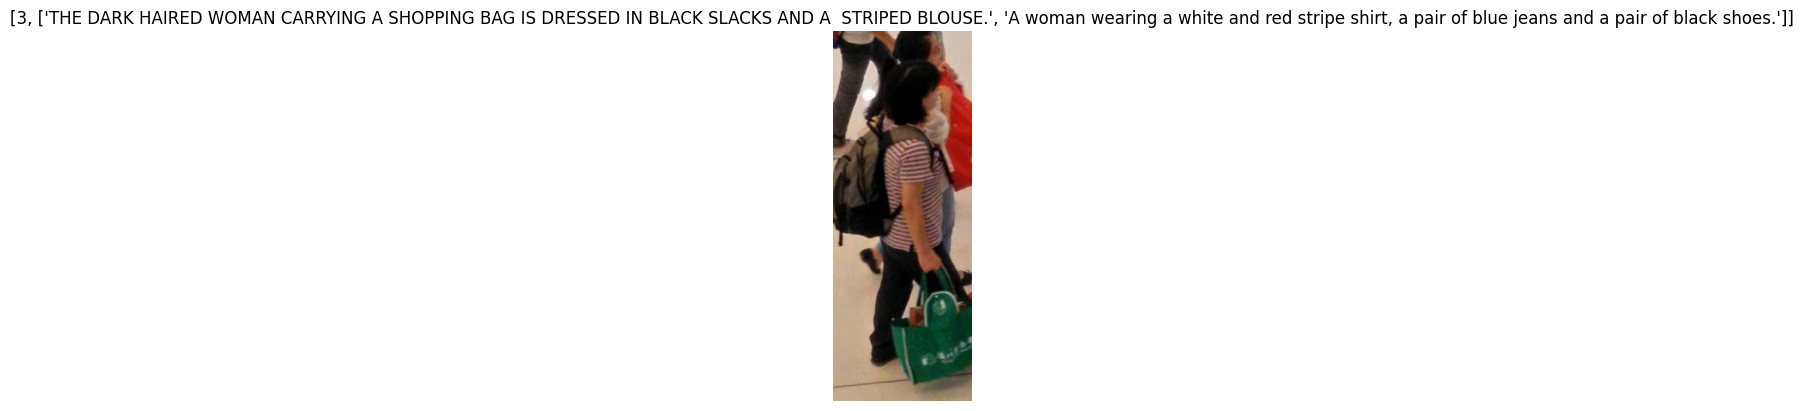

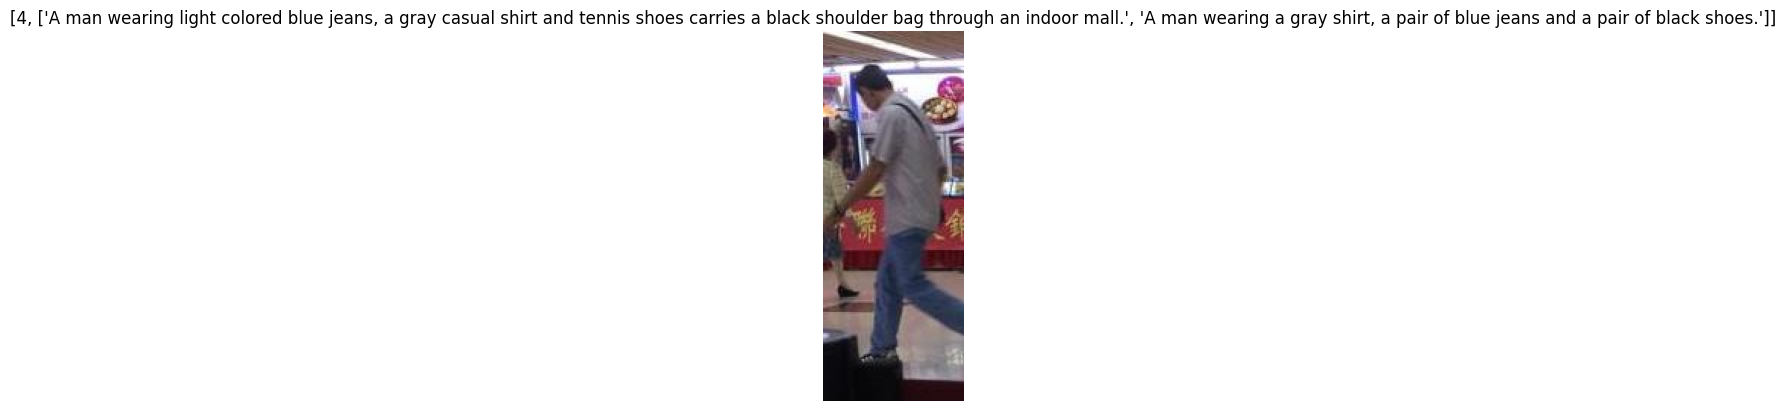

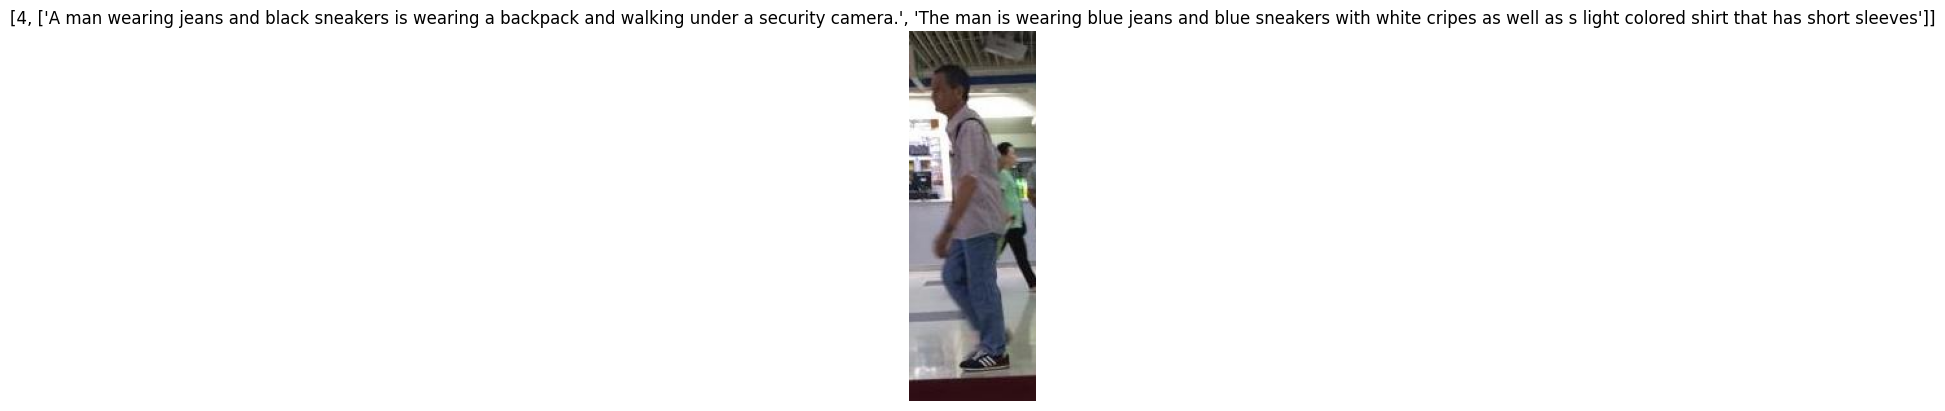

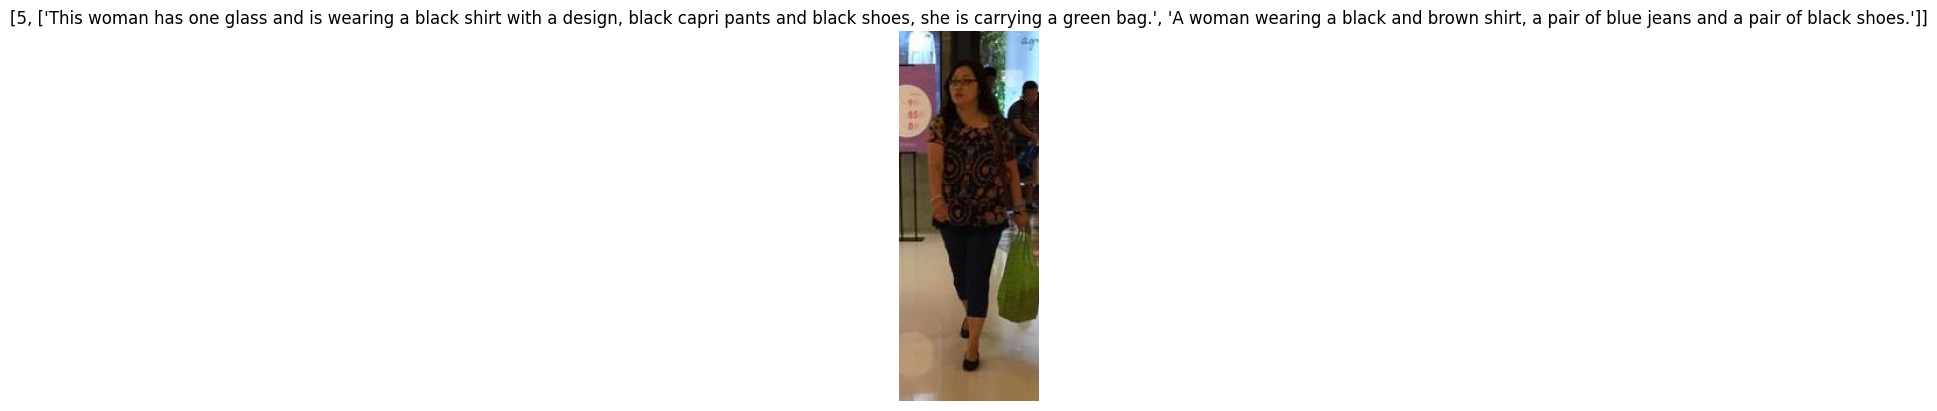

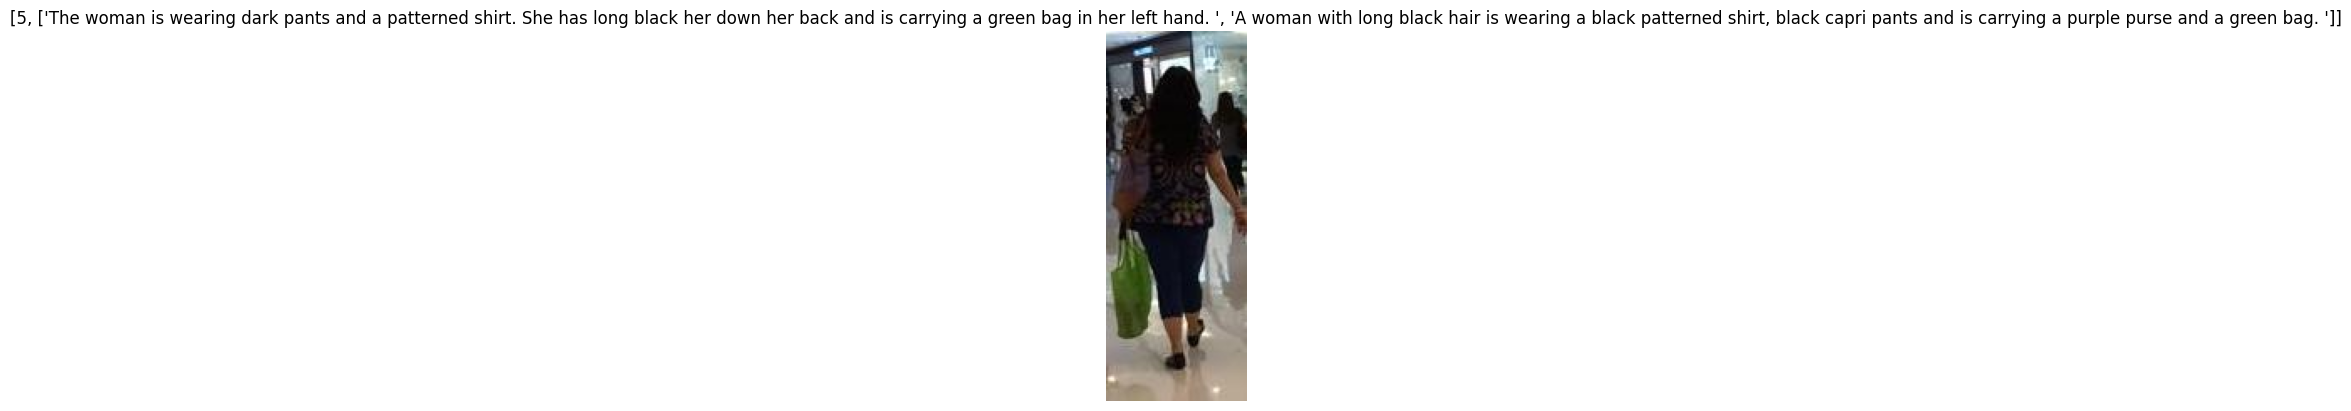

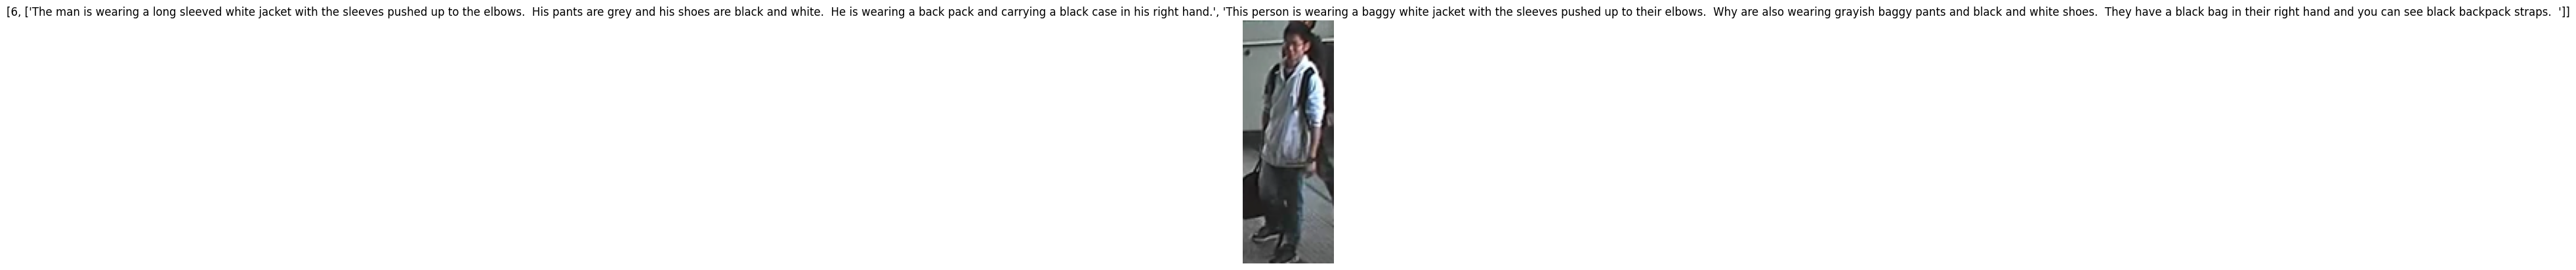

In [137]:
import matplotlib.pyplot as plt
import PIL.Image as Image

CUHK_img_path = '/home/jiahao/task/IRRA/input/images/CUHK-PEDES/imgs'

pid=0  #4102个identity，每个identity有5张图片，每张图片有2个caption
for i in range(pid*15, (pid+1)*15):
    img = Image.open(f"{CUHK_img_path}/{annos[i]['file_path']}").convert('RGB')
    plt.imshow(img)
    plt.title([annos[i]['id'], annos[i]['captions']])
    plt.axis('off')
    plt.show()


# End